# 05 — Explainability: gain importance and SHAP

## What this notebook is for
Explaining the final model — LightGBM with undersampling, after tuning.

Three views, in increasing specificity:
1. **Gain importance** — which variables the trees relied on, globally.
2. **SHAP beeswarm** — global importance *and* the direction of each effect.
3. **SHAP waterfall** — a single decision, explained: one high-risk case and one low-risk case.

The third is the one that matters for a credit decision. An applicant who is refused is entitled to know which of their own characteristics drove that, and a global ranking cannot answer it.

## Reproducibility
The figures are produced by script, not by this notebook:

```
uv run python scripts/explainability.py --model-name credit_scoring_model --log-mlflow
```

The notebook reads them back and interprets them.

In [1]:
from pathlib import Path
import pandas as pd
import mlflow
from mlflow.tracking import MlflowClient

# Project root (the folder holding src)
cwd = Path().resolve()
root = cwd
while root != root.parent and not (root / "src").exists():
    root = root.parent
assert (root / "src").exists()

db_path = (root / "mlflow" / "mlflow.db").resolve()
TRACKING_URI = f"sqlite:///{db_path.as_posix()}"

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_registry_uri(TRACKING_URI)
client = MlflowClient()

REPORT_DIR = (root / "reports" / "explainability").resolve()
FIG_DIR = REPORT_DIR / "figures"

print("DB:", db_path)
print("Report dir:", REPORT_DIR)
print("Figures:", list(FIG_DIR.glob("*.png")))

g:\Mon Drive\OC\Projet_6\credexp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DB: G:\Mon Drive\OC\Projet_6\credexp\mlflow\mlflow.db
Report dir: G:\Mon Drive\OC\Projet_6\credexp\reports\explainability
Figures: [WindowsPath('G:/Mon Drive/OC/Projet_6/credexp/reports/explainability/figures/feature_importance_gain.png'), WindowsPath('G:/Mon Drive/OC/Projet_6/credexp/reports/explainability/figures/shap_beeswarm.png'), WindowsPath('G:/Mon Drive/OC/Projet_6/credexp/reports/explainability/figures/shap_waterfall_high_risk.png'), WindowsPath('G:/Mon Drive/OC/Projet_6/credexp/reports/explainability/figures/shap_waterfall_low_risk.png')]


## Loading the final model from the Model Registry

The model is versioned in the MLflow Model Registry under `credit_scoring_model`. The latest version is loaded here — the same path the API takes, so what is explained is what would be served.

In [2]:
MODEL_NAME = "credit_scoring_model"

versions = client.search_model_versions(f"name='{MODEL_NAME}'")
assert len(versions) > 0, "No versions found in registry"

latest = sorted(versions, key=lambda v: int(v.version))[-1]
print("Latest version:", latest.version, "| run_id:", latest.run_id)

model_uri = f"models:/{MODEL_NAME}/{latest.version}"
pipeline = mlflow.sklearn.load_model(model_uri)

pipeline

Latest version: 2 | run_id: 7663266b67f7497fa57b12a1791d0b1b


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('inf_to_nan', ...), ('imputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputatio

## If the figures are missing

Run the script, then re-run this notebook:

```
uv run python scripts/explainability.py --model-name credit_scoring_model --log-mlflow
```

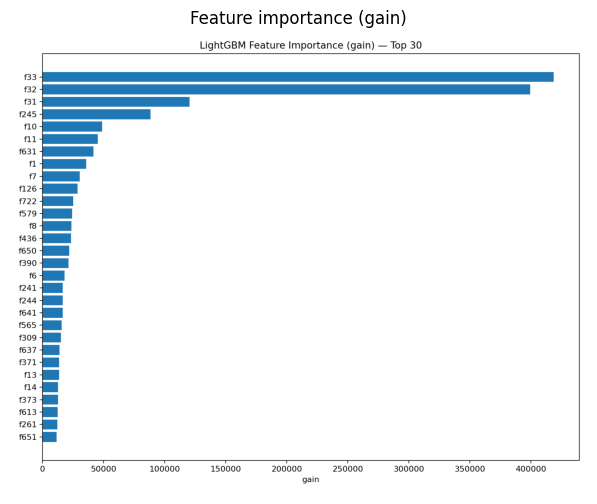

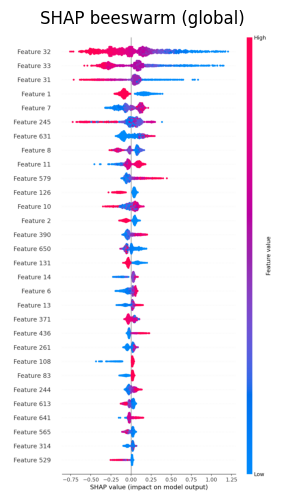

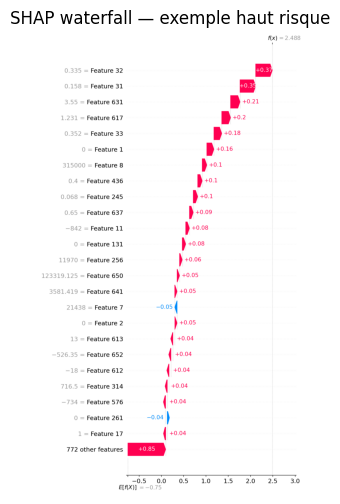

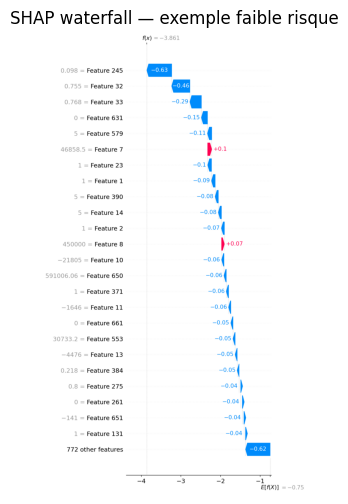

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

def show_image(path: Path, title: str):
    img = Image.open(path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

show_image(FIG_DIR / "feature_importance_gain.png", "Feature importance (gain)")
show_image(FIG_DIR / "shap_beeswarm.png", "SHAP beeswarm (global)")
show_image(FIG_DIR / "shap_waterfall_high_risk.png", "SHAP waterfall — exemple haut risque")
show_image(FIG_DIR / "shap_waterfall_low_risk.png", "SHAP waterfall — exemple faible risque")

## Reading the global views

### Gain importance
How much each variable reduced the loss, averaged over the trees. It is a statement about the **model's structure**, and it depends on the splits the trees happened to make: two correlated variables can share the credit arbitrarily between them.

### SHAP beeswarm
SHAP attributes each prediction additively to its features. The beeswarm shows three things at once: which features matter (vertical order), which direction they push (sign), and how much that varies across applicants (spread).

The two views usually agree on the top variables, and where they disagree it is worth looking rather than dismissing: they measure different things — one the model's internal reliance, the other the effect on the output.

## Reading a single decision

A waterfall starts at the model's average output and shows each feature pushing that particular prediction up towards risk or down away from it.

Two cases, chosen from the sample rather than picked by hand:
1. the applicant with the **highest** predicted probability
2. the applicant with the **lowest**

What this checks is not whether the model is right about them, but whether its reasons are the kind of reasons a person could be given.

## Conclusion

The final model is read through two complementary lenses: gain importance for what the trees leaned on, SHAP for how each feature moves an actual prediction.

Together they cover what a scoring model has to be able to answer — which variables dominate overall, and why *this* applicant received *this* score. Both are needed for the serving side: a score without a reason is not a decision anyone can defend.

One limit to state plainly: this explainability is built for the retained LightGBM model and its `booster_`. It is not a model-agnostic framework, and it would not transfer as-is to the other candidates.